# Logistic Regression Analysis Tool
Select a dataset from the dropdown, then use the **Threshold slider** to explore the trade-off between precision and recall.

| Dataset | Target | 1 means |
|---|---|---|
| Titanic | `survived` | Survived |
| PIMA | `outcome` | Diabetic |
| UCLA | `admit` | Admitted |
| German Credit (All) | `credit_risk` | Good credit — all 1,000 rows |
| German Credit (In-Sample) | `credit_risk` | Good credit — fit & evaluate on same 500 |
| German Credit (Out-of-Sample) | `credit_risk` | Good credit — fit on 500, evaluate on other 500 |

In [1]:
# --- 1. SETUP ---
import pandas as pd
import numpy as np
import os
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Path configuration ───────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    base_dir = '/content/drive/MyDrive/MSFin_Python/data'
except Exception:
    base_dir = '.'

print(f"✅ Data directory: {os.path.abspath(base_dir)}")

Mounted at /content/drive
✅ Data directory: /content/drive/MyDrive/MSFin_Python/data


In [2]:
# --- 2. DATASET REGISTRY ---
# Order matches dropdown sequence: Titanic, PIMA, UCLA, German (All), In-Sample, Out-of-Sample
DATASET_REGISTRY = {
    'Titanic': {
        'file':       'LR_Titanic200.csv',
        'target':     'survived',
        'mappings':   {},
        'dummies':    ['sex', 'pclass', 'embarked'],
        'continuous': ['age', 'fare', 'sibsp', 'parch'],
        'prob_label':  'P(Survived = 1)',
        'class_labels': ('Did Not Survive', 'Survived')
    },
    'PIMA': {
        'file':       'LR_PIMA.csv',
        'target':     'outcome',
        'mappings':   {},
        'dummies':    [],
        'continuous': ['glucose', 'bloodpressure', 'bmi', 'age', 'insulin'],
        'prob_label':  'P(Diabetic = 1)',
        'class_labels': ('Not Diabetic', 'Diabetic')
    },
    'UCLA': {
        'file':       'LR_UCLA.csv',
        'target':     'admit',
        'mappings':   {},
        'dummies':    ['rank'],
        'continuous': ['gre', 'gpa'],
        'prob_label':  'P(Admitted = 1)',
        'class_labels': ('Not Admitted', 'Admitted')
    },
    'German Credit (All)': {
        'file':       'LR_GermanCredit.csv',
        'target':     'credit_risk',
        'mappings':   {},
        'dummies':    [
            'status', 'credit_history', 'purpose', 'savings',
            'employment_duration', 'installment_rate', 'personal_status_sex',
            'other_debtors', 'present_residence', 'property',
            'other_installment_plans', 'housing', 'number_credits',
            'job', 'people_liable', 'telephone', 'foreign_worker'
        ],
        'continuous':  ['duration', 'amount', 'age'],
        'prob_label':  'P(Good Credit = 1)',
        'class_labels': ('Bad', 'Good')
    },
    'German Credit (In-Sample)': {
        'file':       'LR_GermanCredit.csv',
        'target':     'credit_risk',
        'mappings':   {},
        'dummies':    [
            'status', 'credit_history', 'purpose', 'savings',
            'employment_duration', 'installment_rate', 'personal_status_sex',
            'other_debtors', 'present_residence', 'property',
            'other_installment_plans', 'housing', 'number_credits',
            'job', 'people_liable', 'telephone', 'foreign_worker'
        ],
        'continuous':  ['duration', 'amount', 'age'],
        'prob_label':  'P(Good Credit = 1)',
        'class_labels': ('Bad', 'Good'),
        'split':       'in'
    },
    'German Credit (Out-of-Sample)': {
        'file':       'LR_GermanCredit.csv',
        'target':     'credit_risk',
        'mappings':   {},
        'dummies':    [
            'status', 'credit_history', 'purpose', 'savings',
            'employment_duration', 'installment_rate', 'personal_status_sex',
            'other_debtors', 'present_residence', 'property',
            'other_installment_plans', 'housing', 'number_credits',
            'job', 'people_liable', 'telephone', 'foreign_worker'
        ],
        'continuous':  ['duration', 'amount', 'age'],
        'prob_label':  'P(Good Credit = 1)',
        'class_labels': ('Bad', 'Good'),
        'split':       'out'
    }
}
print('Registry loaded:', list(DATASET_REGISTRY.keys()))

Registry loaded: ['Titanic', 'PIMA', 'UCLA', 'German Credit (All)', 'German Credit (In-Sample)', 'German Credit (Out-of-Sample)']


In [3]:
# --- 3. DATA LOADER & PREFLIGHT CHECK ---
def universal_loader(dataset_name):
    recipe = DATASET_REGISTRY[dataset_name]
    path = os.path.join(base_dir, recipe['file'])
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")

    df = pd.read_csv(path)
    df.columns = [c.lower().strip() for c in df.columns]

    if recipe.get('mappings'):
        for col, mapping in recipe['mappings'].items():
            if col in df.columns:
                df[col] = df[col].map(mapping)

    if recipe['dummies']:
        for d_col in recipe['dummies']:
            if d_col in df.columns:
                df[d_col] = df[d_col].astype(str)
        df = pd.get_dummies(df, columns=recipe['dummies'], drop_first=True)

    for col in recipe['continuous']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].fillna(df[col].median())
            df[col] = (df[col] - df[col].mean()) / df[col].std()

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    df = df.fillna(0)

    y = df[recipe['target']].astype(int)
    X = sm.add_constant(df.drop(columns=[recipe['target']]))
    return y, X


def run_preflight_check():
    rows = []
    for name in DATASET_REGISTRY:
        try:
            y, X = universal_loader(name)
            rows.append({
                'Dataset': name,
                'N_Rows': len(y),
                'N_Features (after dummies)': len(X.columns) - 1,
                'Balance (% outcome=1)': f"{y.mean():.1%}",
                'Status': '✅ READY'
            })
        except Exception as e:
            rows.append({'Dataset': name, 'Status': f'❌ {str(e)[:80]}'})
    return pd.DataFrame(rows)

display(run_preflight_check())

,Dataset,N_Rows,N_Features (after dummies),Balance (% outcome=1),Status
0,Titanic,200,10,35.0%,✅ READY
1,PIMA,768,8,34.9%,✅ READY
2,UCLA,400,5,31.8%,✅ READY
3,German Credit (All),1000,54,70.0%,✅ READY
4,German Credit (In-Sample),1000,54,70.0%,✅ READY
5,German Credit (Out-of-Sample),1000,54,70.0%,✅ READY


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


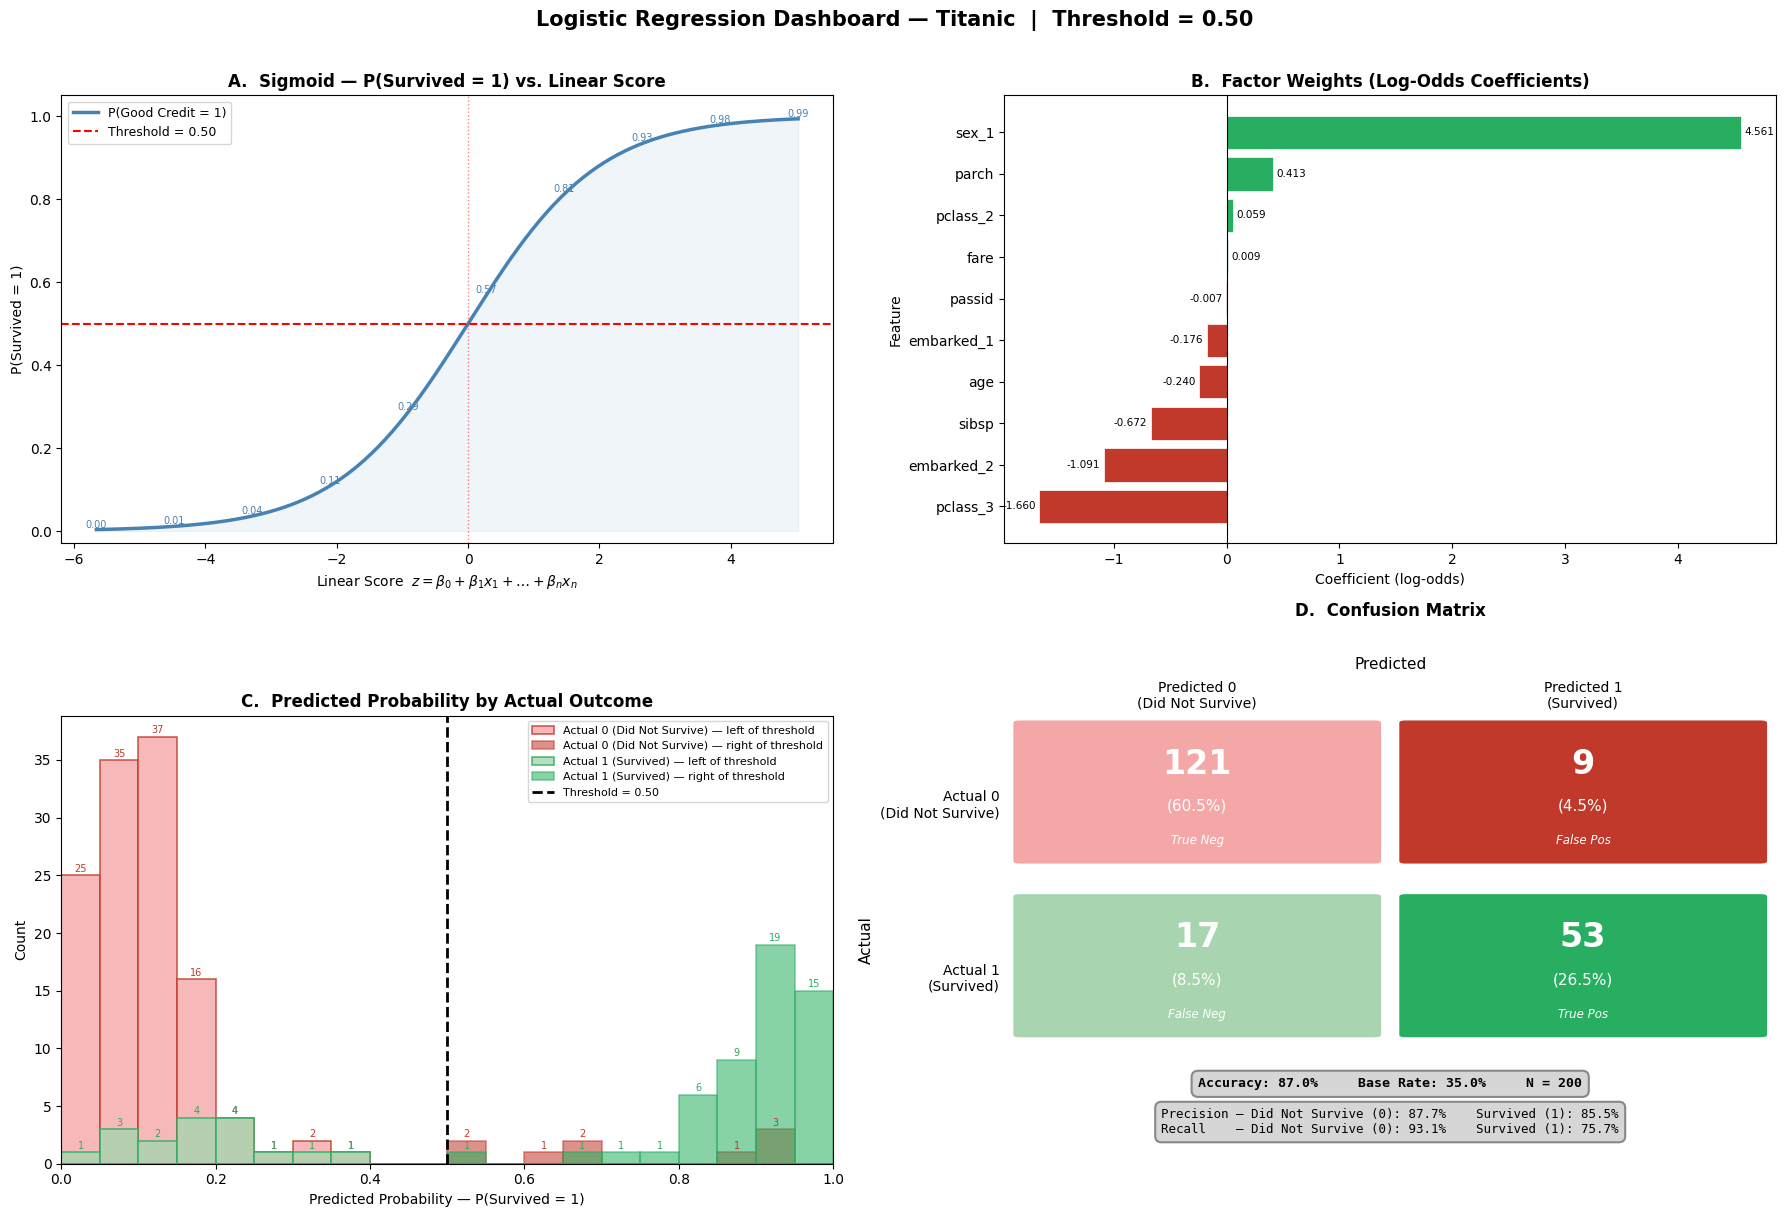

In [4]:
# --- 4. INTERACTIVE DASHBOARD ---

# ── Colour palette ────────────────────────────────────────────────────────────
# Shared across Chart C (histogram) and Chart D (confusion matrix)
# Actual 0       : reds     Actual 1       : greens
# Left of thresh : lighter  Right of thresh: darker
C_TN = '#f4a7a7'   # light red   — True  Negative  (Actual 0, Pred 0)
C_FP = '#c0392b'   # dark  red   — False Positive  (Actual 0, Pred 1)
C_FN = '#a8d5b0'   # light green — False Negative  (Actual 1, Pred 0)
C_TP = '#27ae60'   # dark  green — True  Positive  (Actual 1, Pred 1)

dataset_dropdown = widgets.Dropdown(
    options=list(DATASET_REGISTRY.keys()),
    value='Titanic',
    description='Dataset:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='320px')
)
threshold_slider = widgets.FloatSlider(
    value=0.5, min=0.05, max=0.95, step=0.05,
    description='Threshold:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='420px')
)

from sklearn.model_selection import train_test_split

def update_dashboard(change):
    clear_output(wait=True)
    display(widgets.VBox([dataset_dropdown, threshold_slider]))

    thresh  = threshold_slider.value
    ds_name = dataset_dropdown.value
    recipe  = DATASET_REGISTRY[ds_name]
    prob_label   = recipe['prob_label']
    label0, label1 = recipe['class_labels']

    try:
        # ── Load & fit ────────────────────────────────────────────────────
        y, X = universal_loader(ds_name)
        y        = pd.to_numeric(y, errors='coerce').fillna(0).astype(float)
        X        = X.apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
        X        = X.loc[:, (X != X.iloc[0]).any()]
        if recipe.get('split') == 'in':
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.5, random_state=42)
            model    = sm.Logit(y_train, X_train).fit_regularized(method='l1', alpha=0.1, disp=0)
            y_prob   = model.predict(X_train)   # evaluate on training half
            y        = y_train
            X        = X_train
        elif recipe.get('split') == 'out':
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.5, random_state=42)
            model    = sm.Logit(y_train, X_train).fit_regularized(method='l1', alpha=0.1, disp=0)
            y_prob   = model.predict(X_test)     # evaluate on test half
            y        = y_test
            X        = X_test
        else:
            model    = sm.Logit(y, X).fit_regularized(method='l1', alpha=0.1, disp=0)
            y_prob   = model.predict(X)
        y_pred   = (y_prob >= thresh).astype(int)
        log_odds = model.fittedvalues    # linear predictor  z = Xβ

        # ── 2×2 figure ────────────────────────────────────────────────────
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        ax_sig, ax_coef, ax_hist, ax_cm = (
            axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]
        )

        # ── Chart A : True sigmoid ────────────────────────────────────────
        z_range  = np.linspace(log_odds.min(), log_odds.max(), 300)
        p_range  = 1 / (1 + np.exp(-z_range))
        thresh_z = np.log(thresh / (1 - thresh))   # threshold in log-odds space

        ax_sig.plot(z_range, p_range, color='steelblue', lw=2.5,
                    label='P(Good Credit = 1)')
        ax_sig.fill_between(z_range, p_range, alpha=0.08, color='steelblue')
        ax_sig.axhline(thresh, color='red', linestyle='--', lw=1.5,
                       label=f'Threshold = {thresh:.2f}')
        ax_sig.axvline(thresh_z, color='red', linestyle=':', lw=1, alpha=0.5)

        for z_pt in np.linspace(log_odds.min(), log_odds.max(), 10):
            p_pt = 1 / (1 + np.exp(-z_pt))
            ax_sig.annotate(f'{p_pt:.2f}', xy=(z_pt, p_pt),
                            fontsize=7, color='steelblue',
                            ha='center', va='bottom')

        ax_sig.set_title('A.  Sigmoid — ' + prob_label + ' vs. Linear Score',
                         fontweight='bold')
        ax_sig.set_xlabel(
            r'Linear Score  $z = \beta_0 + \beta_1 x_1 + \ldots + \beta_n x_n$')
        ax_sig.set_ylabel(prob_label)
        ax_sig.legend(fontsize=9)
        ax_sig.set_ylim(-0.03, 1.05)

        # ── Chart B : Factor importance ───────────────────────────────────
        df_res = (pd.DataFrame({'Feature': X.columns, 'Coeff': model.params})
                    .assign(AbsCoeff=lambda d: d['Coeff'].abs())
                    .nlargest(15, 'AbsCoeff')
                    .sort_values('Coeff'))
        colours_b = [C_TP if c > 0 else C_FP for c in df_res['Coeff']]
        bars = ax_coef.barh(df_res['Feature'], df_res['Coeff'],
                            color=colours_b, edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, df_res['Coeff']):
            ax_coef.text(
                val + (0.03 if val >= 0 else -0.03),
                bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=7.5
            )
        ax_coef.axvline(0, color='black', linewidth=0.8)
        ax_coef.set_title('B.  Factor Weights (Log-Odds Coefficients)',
                          fontweight='bold')
        ax_coef.set_xlabel('Coefficient (log-odds)')
        ax_coef.set_ylabel('Feature')

        # ── Chart C : Predicted probability distribution ──────────────────
        # Bars overlap from zero baseline (no stacking, no KDE).
        # Left of threshold = lighter shade, right = darker shade.
        bin_edges = np.linspace(0, 1, 21)   # 20 equal bins

        for actual, col_left, col_right, label in [
            (0, C_TN, C_FP, f'Actual 0 ({label0})'),
            (1, C_FN, C_TP, f'Actual 1 ({label1})')
        ]:
            probs_cls  = y_prob[y == actual]
            left_probs  = probs_cls[probs_cls <  thresh]
            right_probs = probs_cls[probs_cls >= thresh]

            ax_hist.hist(left_probs,  bins=bin_edges, color=col_left,
                         alpha=0.80, edgecolor=col_right, linewidth=1.2,
                         label=f'{label} — left of threshold')
            counts_left, _ = np.histogram(left_probs, bins=bin_edges)
            for count, edge in zip(counts_left, bin_edges[:-1]):
                if count > 0:
                    ax_hist.text(edge + 0.025, count + 0.3, str(count),
                                 ha='center', fontsize=7, color=col_right)
            ax_hist.hist(right_probs, bins=bin_edges, color=col_right,
                         alpha=0.55, edgecolor=col_right, linewidth=1.2,
                         label=f'{label} — right of threshold')
            counts_right, _ = np.histogram(right_probs, bins=bin_edges)
            for count, edge in zip(counts_right, bin_edges[:-1]):
                if count > 0:
                    ax_hist.text(edge + 0.025, count + 0.3, str(count),
                                 ha='center', fontsize=7, color=col_right)

        ax_hist.axvline(thresh, color='black', linestyle='--', lw=2,
                        label=f'Threshold = {thresh:.2f}')
        ax_hist.set_title('C.  Predicted Probability by Actual Outcome',
                          fontweight='bold')
        ax_hist.set_xlabel('Predicted Probability — ' + prob_label)
        ax_hist.set_ylabel('Count')
        ax_hist.set_xlim(0, 1)
        ax_hist.legend(fontsize=8)

        # ── Chart D : Confusion matrix + stats ───────────────────────────
        cm_mat = confusion_matrix(y, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm_mat.ravel()
        n     = len(y)
        acc   = (tp + tn) / n
        prec0 = tn / (tn + fn) if (tn + fn) > 0 else 0
        prec1 = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec0  = tn / (tn + fp) if (tn + fp) > 0 else 0
        rec1  = tp / (tp + fn) if (tp + fn) > 0 else 0

        cell_colours = [[C_TN, C_FP], [C_FN, C_TP]]
        cell_values  = [[tn,   fp  ], [fn,   tp  ]]
        cell_labels  = [['True Neg', 'False Pos'],
                        ['False Neg', 'True Pos']]

        ax_cm.set_xlim(0, 2)
        ax_cm.set_ylim(0, 2.58)   # extra space below for two stacked stat boxes
        ax_cm.invert_yaxis()

        for r in range(2):
            for c in range(2):
                rect = mpatches.FancyBboxPatch(
                    (c + 0.04, r + 0.04), 0.92, 0.80,
                    boxstyle='round,pad=0.02',
                    facecolor=cell_colours[r][c],
                    edgecolor='white', lw=2
                )
                ax_cm.add_patch(rect)
                count = cell_values[r][c]
                pct   = count / n * 100
                lbl   = cell_labels[r][c]
                ax_cm.text(c + 0.50, r + 0.28, f'{count}',
                           ha='center', va='center',
                           fontsize=24, fontweight='bold', color='white')
                ax_cm.text(c + 0.50, r + 0.52, f'({pct:.1f}%)',
                           ha='center', va='center',
                           fontsize=11, color='white')
                ax_cm.text(c + 0.50, r + 0.72, lbl,
                           ha='center', va='center',
                           fontsize=8.5, color='white', style='italic')

        # Stats block — two stacked boxes below the cells
        # Top box: Accuracy / Base Rate / N
        top_stats = f'Accuracy: {acc:.1%}     Base Rate: {y.mean():.1%}     N = {n}'
        ax_cm.text(1.0, 2.12, top_stats,
                   ha='center', va='center', fontsize=9.5,
                   fontweight='bold', family='monospace',
                   bbox=dict(boxstyle='round,pad=0.5',
                             facecolor='#d6d6d6',
                             edgecolor='#888888', lw=1.5))
        # Bottom box: Precision & Recall
        bot_stats = (
            f'Precision — {label0} (0): {prec0:.1%}    {label1} (1): {prec1:.1%}\n'
            f'Recall    — {label0} (0): {rec0:.1%}    {label1} (1): {rec1:.1%}'
        )
        ax_cm.text(1.0, 2.34, bot_stats,
                   ha='center', va='center', fontsize=9,
                   family='monospace',
                   bbox=dict(boxstyle='round,pad=0.5',
                             facecolor='#d6d6d6',
                             edgecolor='#888888', lw=1.5))

        ax_cm.set_xticks([0.5, 1.5])
        ax_cm.set_xticklabels([f'Predicted 0\n({label0})', f'Predicted 1\n({label1})'],
                               fontsize=10)
        ax_cm.set_yticks([0.5, 1.5])
        ax_cm.set_yticklabels([f'Actual 0\n({label0})', f'Actual 1\n({label1})'],
                               fontsize=10)
        ax_cm.xaxis.set_label_position('top')
        ax_cm.xaxis.tick_top()
        ax_cm.set_xlabel('Predicted', fontsize=11, labelpad=8)
        ax_cm.set_ylabel('Actual', fontsize=11)
        ax_cm.set_title('D.  Confusion Matrix', fontweight='bold', pad=30)
        ax_cm.tick_params(length=0)
        for spine in ax_cm.spines.values():
            spine.set_visible(False)

        plt.suptitle(
            f'Logistic Regression Dashboard — {ds_name}  |  Threshold = {thresh:.2f}',
            fontsize=15, fontweight='bold', y=1.01
        )
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f'❌ Dashboard Error: {e}')
        import traceback; traceback.print_exc()

dataset_dropdown.observe(update_dashboard, names='value')
threshold_slider.observe(update_dashboard, names='value')
update_dashboard(None)